In [1]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


In [2]:
imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/dataset-icdar2024_occluded/val_001.png", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape


In [5]:
import pandas as pd
ok = True
trainset = ["../dat/imgTeste.png", "../dat/imgObjetos.png", "../dat/cable.png"]
for i in range(len(trainset)):
    img = cv.imread(trainset[i], cv.IMREAD_GRAYSCALE)
    (img_rows, img_cols) = img.shape
    tree = mmcfilters.ComponentTree(img.ravel(), img_rows, img_cols)
    features, attrs = mmcfilters.Attribute.computerBasicAttributes(tree)
    
    df2 = pd.DataFrame(attrs, columns=features)
    if( len( df2[df2.isna().any(axis=1)]  ) > 0 ):
        print(i, df2[df2.isna().any(axis=1)] )
        ok = False
    #else:
    #    display.display(df2)
if(ok):
    print("Atributos verificados, tudo ok!")

Atributos verificados, tudo ok!


In [7]:
maxtree = mmcfilters.ComponentTree(imgInput, num_rows, num_cols, True, 1.5)
mintree = mmcfilters.ComponentTree(imgInput, num_rows, num_cols, False, 1.5)
tos = mmcfilters.ComponentTree(imgInput, num_rows, num_cols)

filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)

dic, attrs_maxtree = mmcfilters.Attribute.computerBasicAttributes(maxtree)
dic, attrs_mintree = mmcfilters.Attribute.computerBasicAttributes(mintree)
dic, attrs_tos = mmcfilters.Attribute.computerBasicAttributes(tos)
dic

{'AREA': 0,
 'VOLUME': 1,
 'LEVEL': 2,
 'MEAN_LEVEL': 3,
 'VARIANCE_LEVEL': 4,
 'STANDARD_DEVIATION': 5,
 'BOX_WIDTH': 6,
 'BOX_HEIGHT': 7,
 'RECTANGULARITY': 8,
 'RATIO_WH': 9,
 'CENTRAL_MOMENT_20': 10,
 'CENTRAL_MOMENT_02': 11,
 'CENTRAL_MOMENT_11': 12,
 'CENTRAL_MOMENT_30': 13,
 'CENTRAL_MOMENT_03': 14,
 'CENTRAL_MOMENT_21': 15,
 'CENTRAL_MOMENT_12': 16,
 'ORIENTATION': 17,
 'LENGTH_MAJOR_AXIS': 18,
 'LENGTH_MINOR_AXIS': 19,
 'ECCENTRICITY': 20,
 'COMPACTNESS': 21,
 'HU_MOMENT_1_INERTIA': 22,
 'HU_MOMENT_2': 23,
 'HU_MOMENT_3': 24,
 'HU_MOMENT_4': 25,
 'HU_MOMENT_5': 26,
 'HU_MOMENT_6': 27,
 'HU_MOMENT_7': 28}

In [9]:
from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back
printTree = PrettyPrintTree(
    lambda node: node.children,
    lambda node: ("id:" + str(node.id) + " " + str(node.isMaxtree)[0], "level:" + str(node.level) + " (" + str(node.residue) + ")", "|cnps|:" + str(len(node.cnps))  ), 
    color=Back.BLACK + Fore.WHITE
)

In [11]:
printTree(tos.root)

sum=0
for node in tos.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

                                                                      ('id:0 F', 'level:203 (203)', '|cnps|:89121') 
                      ┌─────────────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────────────────────────┐
 ('id:1 F', 'level:126 (77)', '|cnps|:24901')                          ('id:3 F', 'level:78 (125)', '|cnps|:71014')                           ('id:9 F', 'level:54 (149)', '|cnps|:15485') 
                      |                                              ┌──────────────────────┴───────────────────────┐                                                                      
  ('id:2 F', 'level:72 (54)', '|cnps|:8929')    ('id:4 T', 'level:126 (48)', '|cnps|:17592')   ('id:6 T', 'level:161 (83)', '|cnps|:13119')                                                
                                                                     |                                              |                                     

(250000, 250000)

In [13]:
printTree(maxtree.root)
sum=0
for node in maxtree.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

                                                 ('id:0 F', 'level:38 (38)', '|cnps|:6821') 
                                                                     |
                                                  ('id:1 T', 'level:39 (1)', '|cnps|:421') 
                                                                     |
                                                ('id:2 T', 'level:54 (15)', '|cnps|:18082') 
                                                                     |
                                                 ('id:3 T', 'level:72 (18)', '|cnps|:8929') 
                                                                     |
                                                 ('id:4 T', 'level:78 (6)', '|cnps|:71014') 
                      ┌──────────────────────────────────────────────┼──────────────────────────────────────────────┐
 ('id:5 T', 'level:126 (48)', '|cnps|:17592')   ('id:6 T', 'level:126 (48)', '|cnps|:24901')   ('id:7 T', 'level:161 (83)', '|cnps|:13

(250000, 250000)

In [15]:
printTree(mintree.root)
sum=0
for node in mintree.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

                                                                                                                        ('id:0 F', 'level:203 (203)', '|cnps|:89121') 
                                                                              ┌───────────────────────────────────────────────────────────────┴────────────────┬──────────────────────────────────────────────┐
                                                         ('id:1 F', 'level:161 (42)', '|cnps|:13119')                                     ('id:3 F', 'level:126 (77)', '|cnps|:24901')   ('id:6 F', 'level:54 (149)', '|cnps|:15485') 
                                            ┌─────────────────────────────────┴──────────────────────────────────┐                                             |                                                                      
                       ('id:2 F', 'level:126 (35)', '|cnps|:17592')                         ('id:7 F', 'level:54 (107)', '|cnps|:2597')    ('id:5 F', 'level:72 (54

(250000, 250000)

Text(0.5, 1.0, 'attribute filter (tos)')

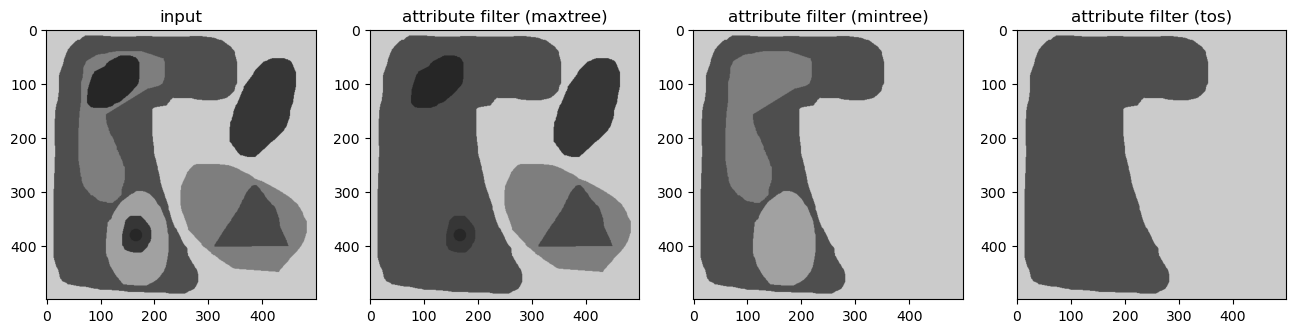

In [19]:
attr_type = dic['BOX_HEIGHT']
threshold = 400

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringDirectRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringDirectRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringDirectRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'attribute filter (tos)')

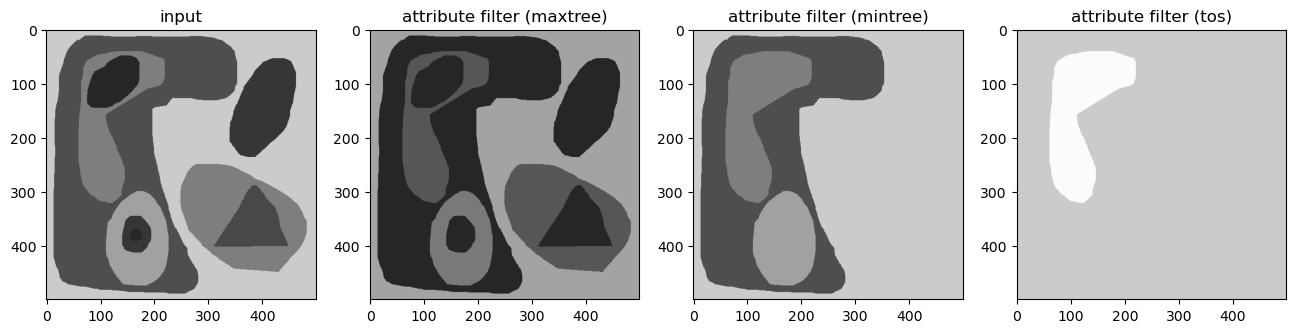

In [21]:
attr_type = dic['HU_MOMENT_1_INERTIA']
threshold = 0.2

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringSubtractiveRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringSubtractiveRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringSubtractiveRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'negative residues')

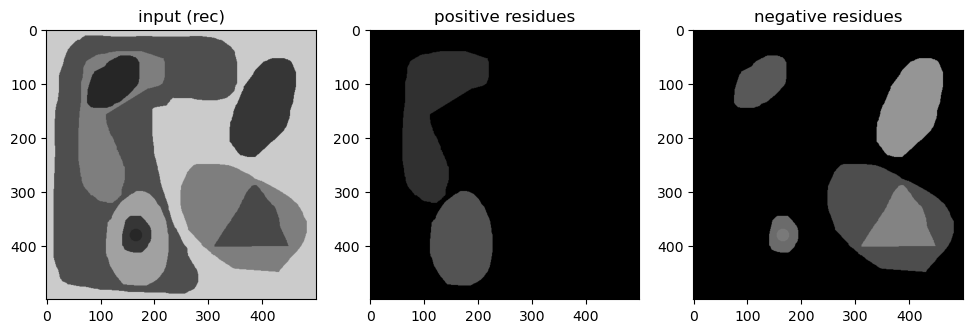

In [23]:
attr_type = dic['BOX_HEIGHT']
max_threshold = 300
attr_tos = attrs_tos[:,attr_type]
deltaMSER=5
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tos, attr_tos, max_threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgRest = primitives.restOfImage
imgRec = rtree.reconstruction()
imgPos = rtree.getPositiveResidues()
imgNeg = rtree.getNegativeResidues()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgPos.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('positive residues')

plt.subplot(1,4, 3)
plt.imshow(imgNeg.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('negative residues')


Text(0.5, 1.0, 'residual filter')

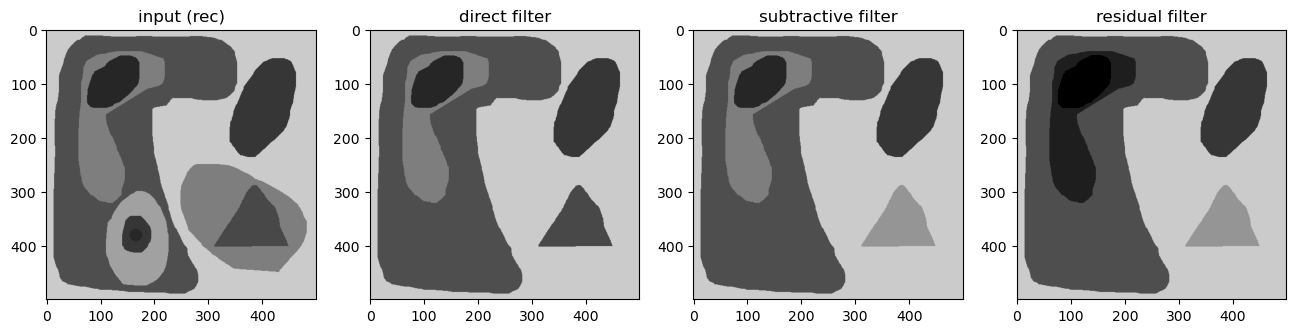

In [25]:
attr_type = dic['HU_MOMENT_1_INERTIA']
threshold = 0.18
att_tos = attrs_tos[:,attr_type]

filterToS = mmcfilters.AttributeFilters(tos)
imgAttrFilter = filterToS.filteringDirectRule(att_tos > threshold)
imgAttrSub = filterToS.filteringSubtractiveRule(att_tos > threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgResFilter = rtree.filtering(att_tos > threshold)

imgRec = rtree.reconstruction()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgAttrFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('direct filter')

plt.subplot(1,4, 3)
plt.imshow(imgAttrSub.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('subtractive filter')


plt.subplot(1,4, 4)
plt.imshow(imgResFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter')
